# **Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Install the category_encoders library if not already installed
!pip install category_encoders
from category_encoders import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

# **Read&Load**

In [ ]:
#reading data

data = pd.read_csv("predictive_maintenance.csv")

In [ ]:
#first 5 rows in data
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [ ]:
#last 5 rows in data
data.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,No Failure
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,No Failure
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,No Failure
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,No Failure
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,No Failure


In [ ]:
#how many rows and columns in data
data.shape

(10000, 10)

# **EDA**

In [ ]:
#returns columns with number of null values and its type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
#statistical summary to whole data
data.describe(include = 'all')

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,L57163,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN


In [ ]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]
    duplicates=data.duplicated().sum()


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          'Duplicates':duplicates})
    return info_df

In [ ]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,UDI,int64,"[9984, 9983, 9982, 9981, 9980, 9979, 9978, 997...",10000,0,0.0,0
1,Product ID,object,"[L57163, M24842, L57161, L57160, L57159, H3939...",10000,0,0.0,0
2,Type,object,"[L, M, H]",3,0,0.0,0
3,Air temperature [K],float64,"[300.7, 298.9, 297.4, 300.5, 298.8, 300.6, 298...",93,0,0.0,0
4,Process temperature [K],float64,"[310.6, 310.8, 310.7, 308.6, 310.5, 310.1, 308...",82,0,0.0,0
5,Rotational speed [rpm],int64,"[1452, 1435, 1447, 1469, 1429, 1479, 1507, 145...",941,0,0.0,0
6,Torque [Nm],float64,"[40.2, 35.8, 42.4, 38.5, 37.7, 38.2, 40.6, 39....",577,0,0.0,0
7,Tool wear [min],int64,"[0, 2, 5, 7, 59, 119, 166, 9, 181, 148]",246,0,0.0,0
8,Target,int64,"[0, 1]",2,0,0.0,0
9,Failure Type,object,"[No Failure, Heat Dissipation Failure, Power F...",6,0,0.0,0


Failure Type ,Type -> categoral columns

Air temperature [K] ,Rotational speed [rpm] ,Torque [Nm]	,Tool wear [min]-> numerical column

Target -> target

# **Data Visualizations & Exploratory Data Analysis (EDA)**

In this section, we present several visualizations to understand the distributions, relationships, and characteristics of the dataset, specifically focusing on the machine failures.

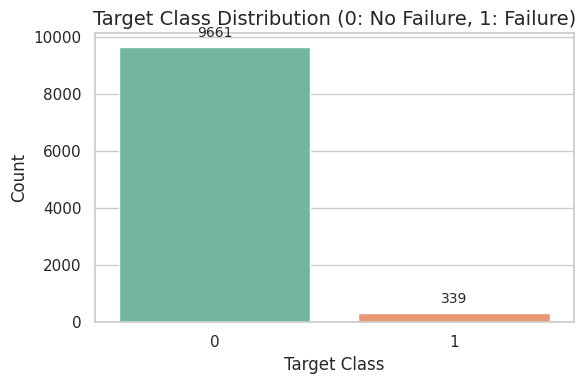

Target class counts:
Target
0    9661
1     339
Name: count, dtype: int64
Failure Rate: 3.39%


In [ ]:
# Set style
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')

# 1. Target / Class Distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x='Target', palette='Set2')
plt.title('Target Class Distribution (0: No Failure, 1: Failure)', fontsize=14)
plt.xlabel('Target Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

print('Target class counts:')
print(data['Target'].value_counts())
print(f"Failure Rate: {data['Target'].mean() * 100:.2f}%")

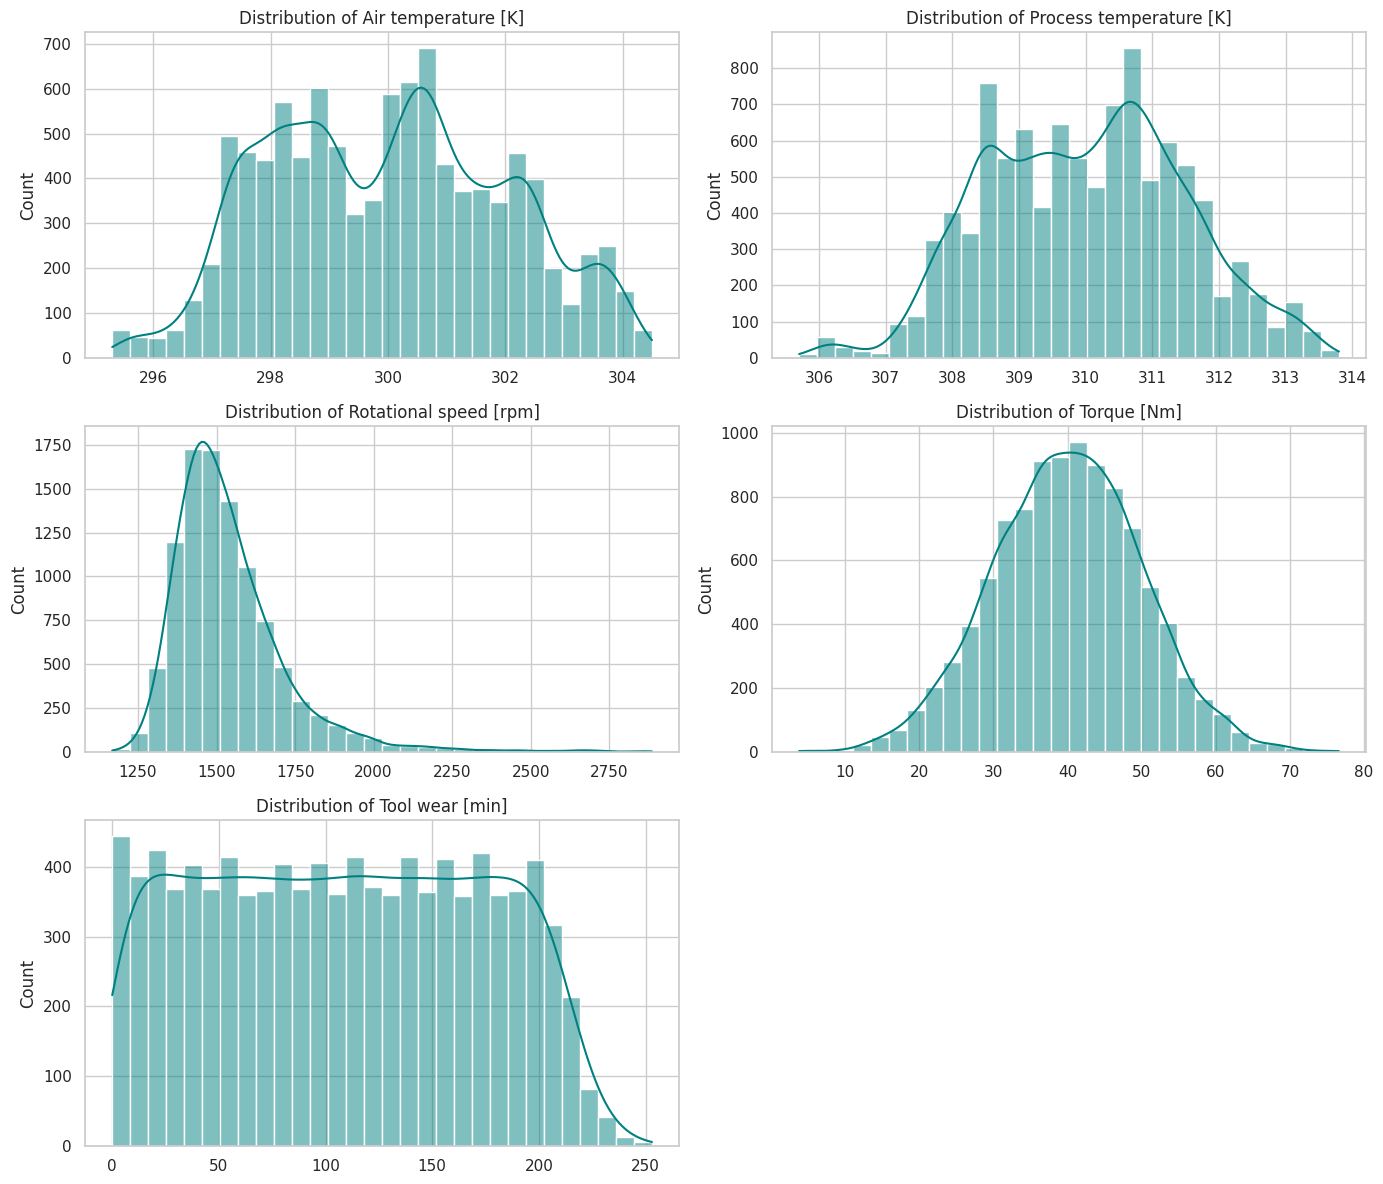

In [ ]:
# 2. Numerical Feature Distributions
numerical_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_xlabel('')

# Delete the unused 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

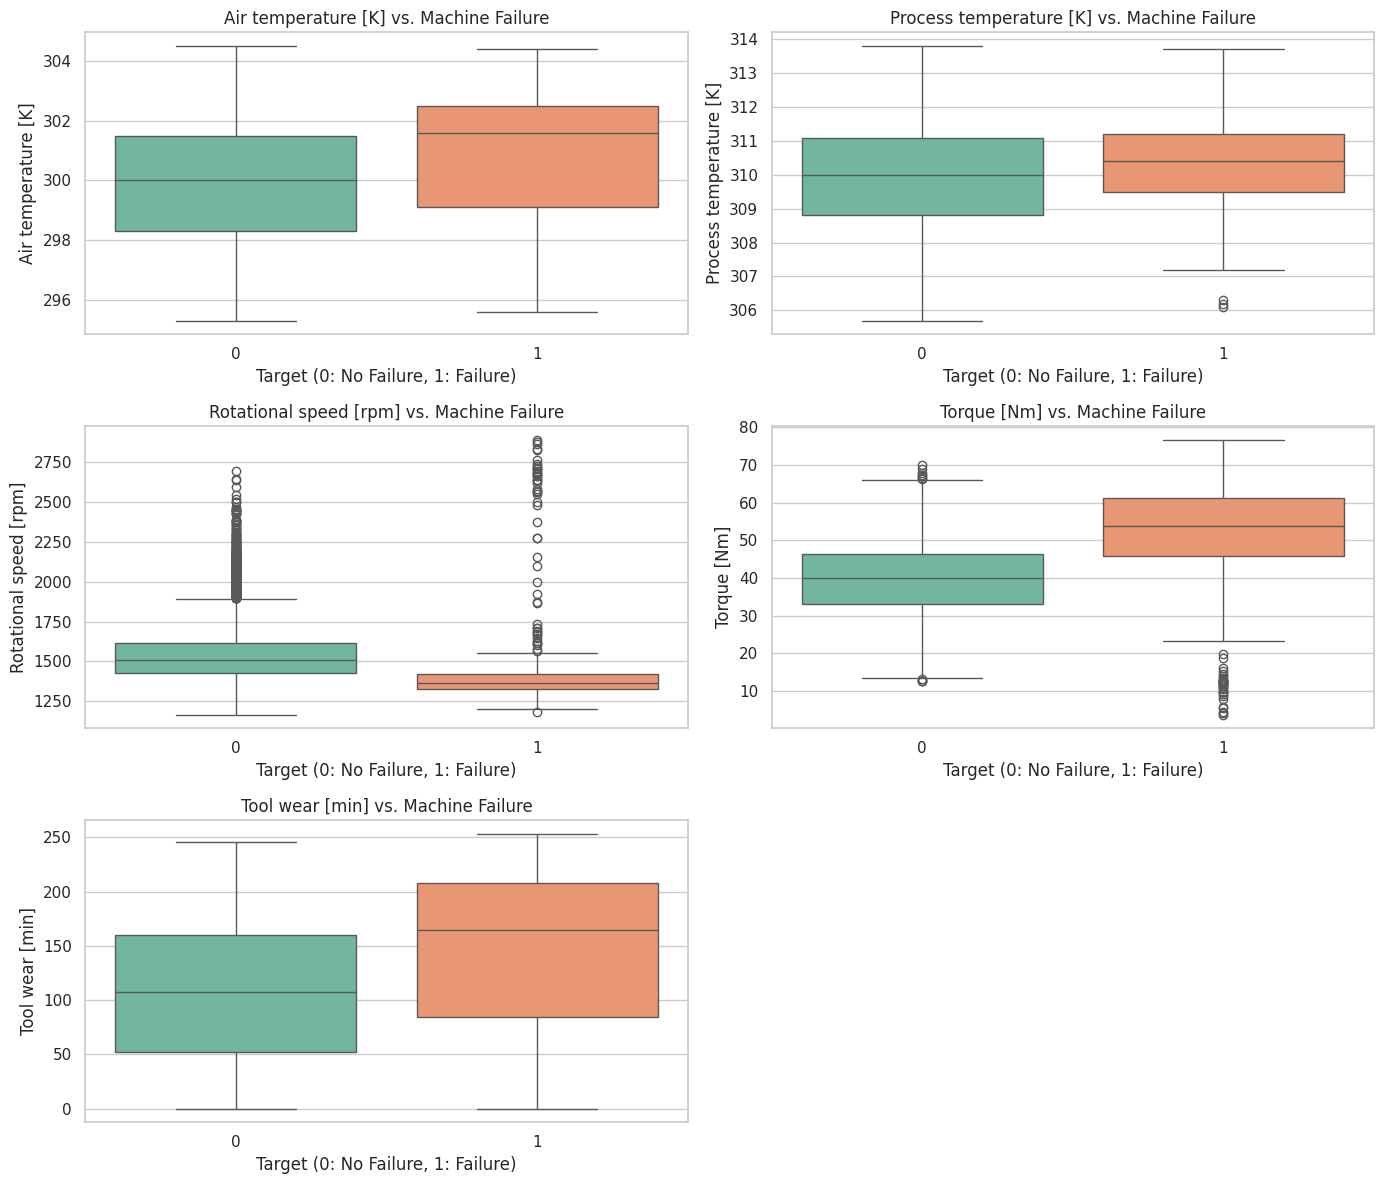

In [ ]:
# 3. Boxplots: Numerical Features vs. Target (Failure vs. Non-Failure)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=data, x='Target', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs. Machine Failure', fontsize=12)
    axes[i].set_xlabel('Target (0: No Failure, 1: Failure)')
    axes[i].set_ylabel(col)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

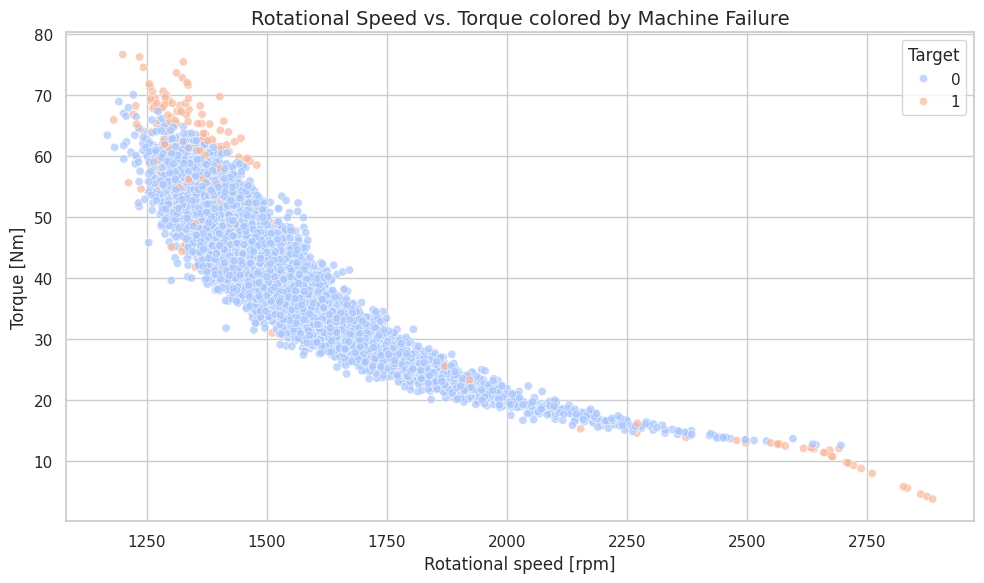

In [ ]:
# 4. Rotational Speed vs. Torque Analysis (showing the failure boundary)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Target', alpha=0.7, palette='coolwarm')
plt.title('Rotational Speed vs. Torque colored by Machine Failure', fontsize=14)
plt.xlabel('Rotational speed [rpm]', fontsize=12)
plt.ylabel('Torque [Nm]', fontsize=12)
plt.legend(title='Target')
plt.tight_layout()
plt.show()

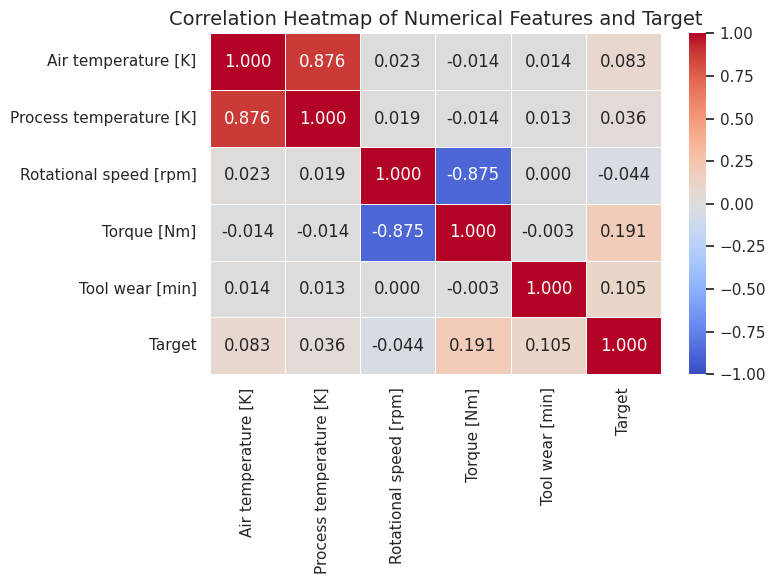

In [ ]:
# 5. Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = data[numerical_cols + ['Target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features and Target', fontsize=14)
plt.tight_layout()
plt.show()

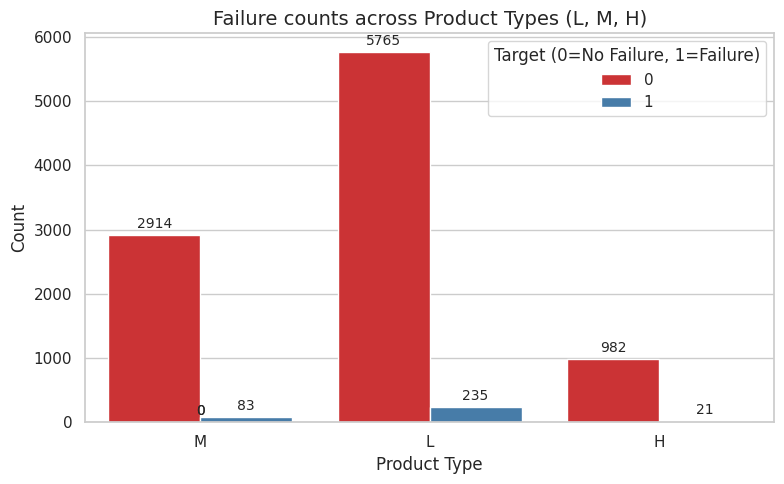

Failure rates by Product Type:
Type
H    2.093719
L    3.916667
M    2.769436
Name: Target, dtype: float64


In [ ]:
# 6. Product Type Analysis and failure rates
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=data, x='Type', hue='Target', palette='Set1')
plt.title('Failure counts across Product Types (L, M, H)', fontsize=14)
plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Target (0=No Failure, 1=Failure)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.show()

print('Failure rates by Product Type:')
print(data.groupby('Type')['Target'].mean() * 100)

# **preprocessing**

In [ ]:
data.drop(columns=['UDI','Product ID','Failure Type'], inplace=True)

In [ ]:
data_info(data)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls,Duplicates
0,Type,object,"[L, M, H]",3,0,0.0,0
1,Air temperature [K],float64,"[300.7, 298.9, 297.4, 300.5, 298.8, 300.6, 298...",93,0,0.0,0
2,Process temperature [K],float64,"[310.6, 310.8, 310.7, 308.6, 310.5, 310.1, 308...",82,0,0.0,0
3,Rotational speed [rpm],int64,"[1452, 1435, 1447, 1469, 1429, 1479, 1507, 145...",941,0,0.0,0
4,Torque [Nm],float64,"[40.2, 35.8, 42.4, 38.5, 37.7, 38.2, 40.6, 39....",577,0,0.0,0
5,Tool wear [min],int64,"[0, 2, 5, 7, 59, 119, 166, 9, 181, 148]",246,0,0.0,0
6,Target,int64,"[0, 1]",2,0,0.0,0


In [ ]:
data.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target'],
      dtype='object')

# **Splint into x & y**

In [ ]:
x= data.drop(columns=['Target'])
y= data['Target']

In [ ]:
# Splitting data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Outliers

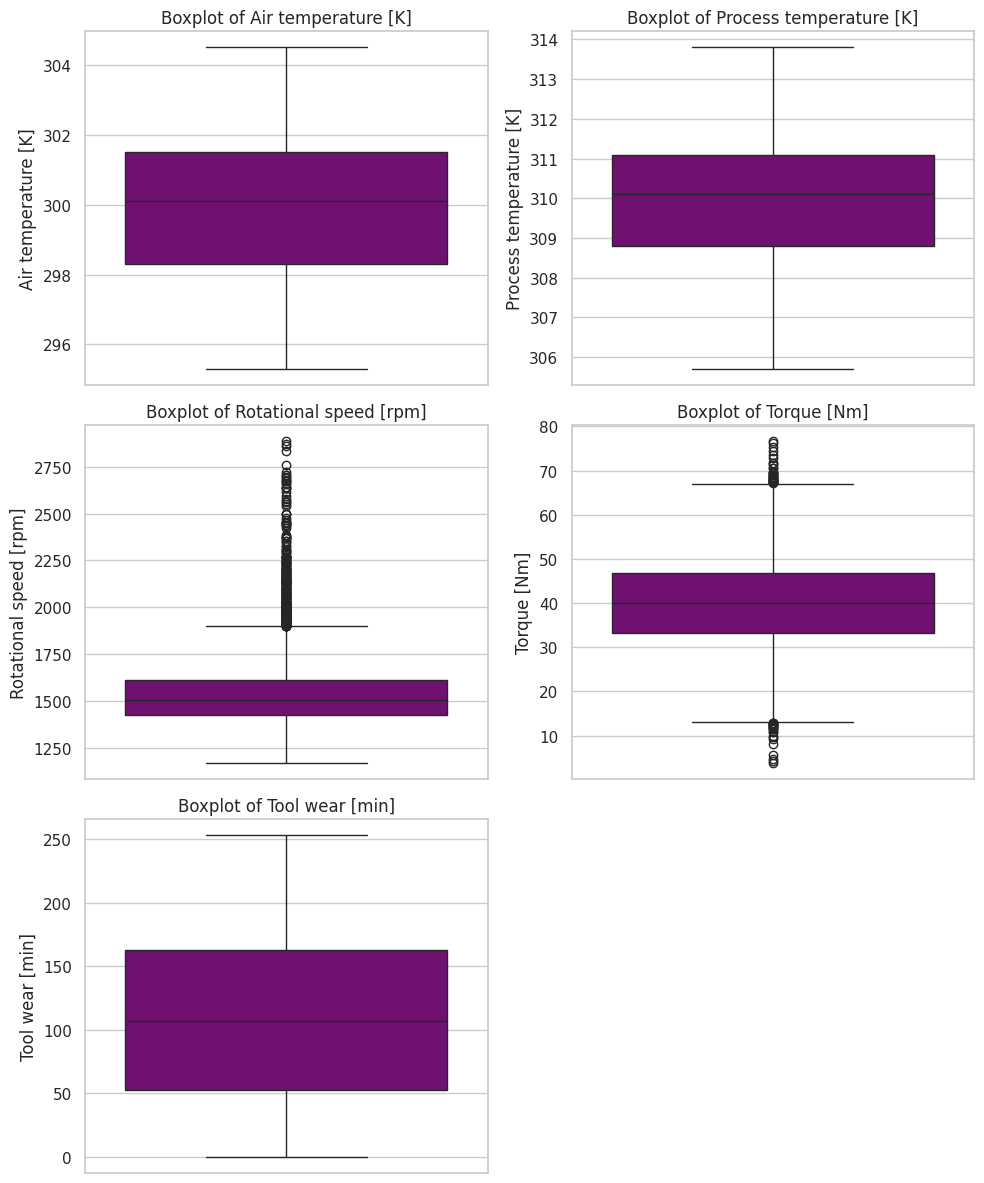

In [ ]:
checkOutliers=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

# Calculate the number of plots needed and determine the layout
n_plots = len(checkOutliers)
# Display in 3 rows, so calculate columns needed (ceiling division)
n_cols_display = 2 # Let's aim for 2 columns per row
n_rows_display = (n_plots + n_cols_display - 1) // n_cols_display # Ceiling division

# Adjust the figure and axes creation to match the new layout
fig, axes = plt.subplots(n_rows_display, n_cols_display, figsize=(5 * n_cols_display, 4 * n_rows_display)) # Adjusted figsize

axes = axes.flatten()

for i, col in enumerate(checkOutliers):
    # Using a single color string instead of a colormap for the 'color' argument
    sns.boxplot(data=x_train, y=col, ax=axes[i], color='purple', whis=1.5)
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

# Remove any unused subplots
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Q1=data['Torque [Nm]'].quantile(0.25)
# Q3=data['Torque [Nm]'].quantile(0.75)
# IQR=Q3-Q1

# lower_bound=Q1-(1.5*IQR)
# upper_bound=Q3+(1.5*IQR)

# data['Torque [Nm]']=np.where(data['Torque [Nm]']<lower_bound,lower_bound,data['Torque [Nm]'])
# data['Torque [Nm]']=np.where(data['Torque [Nm]']>upper_bound,upper_bound,data['Torque [Nm]'])

In [ ]:
# Q1=data['Rotational speed [rpm]'].quantile(0.25)
# Q3=data['Rotational speed [rpm]'].quantile(0.75)
# IQR=Q3-Q1

# lower_bound=Q1-(1.5*IQR)
# upper_bound=Q3+(1.5*IQR)

# data['Rotational speed [rpm]']=np.where(data['Rotational speed [rpm]']<lower_bound,lower_bound,data['Rotational speed [rpm]'])
# data['Rotational speed [rpm]']=np.where(data['Rotational speed [rpm]']>upper_bound,upper_bound,data['Rotational speed [rpm]'])

In [ ]:
# checkOutliers=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

# # Calculate the number of plots needed and determine the layout
# n_plots = len(checkOutliers)
# # Display in 3 rows, so calculate columns needed (ceiling division)
# n_cols_display = 2 # Let's aim for 2 columns per row
# n_rows_display = (n_plots + n_cols_display - 1) // n_cols_display # Ceiling division

# # Adjust the figure and axes creation to match the new layout
# fig, axes = plt.subplots(n_rows_display, n_cols_display, figsize=(5 * n_cols_display, 4 * n_rows_display)) # Adjusted figsize

# axes = axes.flatten()

# for i, col in enumerate(checkOutliers):
#     # Using a single color string instead of a colormap for the 'color' argument
#     sns.boxplot(data=data, y=col, ax=axes[i], color='purple', whis=1.5)
#     axes[i].set_title(f'Boxplot of {col}', fontsize=12)
#     axes[i].set_xlabel('')
#     axes[i].set_ylabel(col)

# # Remove any unused subplots
# for j in range(n_plots, len(axes)):
#     fig.delaxes(axes[j])

# plt.tight_layout()
# plt.show()

# **Encode**

In [ ]:
x_train.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='object')

In [ ]:
Nominal_Cols = ["Type"]#,"Failure Type"]
Numerical_Cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [ ]:
# Install the category_encoders library if not already installed
!pip install category_encoders
from category_encoders import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(
    cols=Nominal_Cols,
    use_cat_names=True
)

x_train = encoder.fit_transform(x_train)
x_test = encoder.transform(x_test)

print(f"One-hot encoded nominal columns: {Nominal_Cols}")
print("x_train head after encoding:")
print(x_train.head())

One-hot encoded nominal columns: ['Type']
x_train head after encoding:
      Type_M  Type_L  Type_H  Air temperature [K]  Process temperature [K]  \
4058       1       0       0                302.0                    310.9   
1221       1       0       0                297.0                    308.3   
6895       1       0       0                301.0                    311.6   
9863       0       1       0                298.9                    309.8   
8711       0       1       0                297.1                    308.5   

      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
4058                    1456         47.2               54  
1221                    1399         46.4              132  
6895                    1357         45.6              137  
9863                    1411         56.3               84  
8711                    1733         28.7               50  


# **Scale**

In [ ]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()
x_train[Numerical_Cols] = scale.fit_transform(x_train[Numerical_Cols])
x_test[Numerical_Cols] = scale.transform(x_test[Numerical_Cols])

## Balancing Data

In [ ]:
print(y_train.value_counts())

Target
0    7729
1     271
Name: count, dtype: int64


In [ ]:
y_train=y_train.astype('int')
y_test=y_test.astype('int')

In [ ]:
# # Generates new synthetic samples
# from imblearn.over_sampling import SMOTE
# smote=SMOTE(random_state=42)
# x_train, y_train = smote.fit_resample(x_train, y_train)

# print(y_train.value_counts())

# **Model**

## Logistic Regression With Grid Search

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train, y_train)

best_log_reg = grid_search.best_estimator_

y_pred = best_log_reg.predict(x_test)
y_pred_train = best_log_reg.predict(x_train)

print("Best Parameters:", grid_search.best_params_)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))

print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Failure', 'Failure']
))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2'}
Train Accuracy: 0.82175
Test Accuracy: 0.8245

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.82      0.90      1932
     Failure       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



--------------------------------------------------------------

## XGBoost with Grid Search

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

# Rename columns to remove special characters for XGBoost compatibility
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.replace('[K]', '').replace('[rpm]', '').replace('[Nm]', '').replace('[min]', '').replace(' ', '_').replace('[', '').replace(']', '')
        new_cols.append(new_col)
    df.columns = new_cols
    return df

x_train_cleaned = clean_col_names(x_train.copy())
x_test_cleaned = clean_col_names(x_test.copy())

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, 28.5]
}

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(x_train_cleaned, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(x_test_cleaned)

print("Best Parameters:", grid_search_xgb.best_params_)

print("Test Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['No Failure', 'Failure']
    )
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'scale_pos_weight': 1}
Test Accuracy: 0.9865

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.89      0.69      0.78        68

    accuracy                           0.99      2000
   macro avg       0.94      0.84      0.88      2000
weighted avg       0.99      0.99      0.99      2000



--------------------------------------------------------------

## Decision Tree With Grid Search

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(x_train, y_train)

best_dt = grid_search_dt.best_estimator_

y_pred_dt = best_dt.predict(x_test)

y_pred_train_dt = best_dt.predict(x_train)

print("Best Parameters:", grid_search_dt.best_params_)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_dt))

print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=['No Failure', 'Failure']
    )
)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters: {'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Train Accuracy: 0.99
Test Accuracy: 0.986

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.80      0.78      0.79        68

    accuracy                           0.99      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.99      0.99      0.99      2000



--------------------------------------------------------------

## RandomForest with Grid Search

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(x_train, y_train)

best_rf = grid_search_rf.best_estimator_

y_pred_rf = best_rf.predict(x_test)

y_pred_train_rf = best_rf.predict(x_train)

print("Best Parameters:", grid_search_rf.best_params_)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_rf))

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['No Failure', 'Failure']
    )
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Train Accuracy: 0.999
Test Accuracy: 0.9805

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.78      0.59      0.67        68

    accuracy                           0.98      2000
   macro avg       0.88      0.79      0.83      2000
weighted avg       0.98      0.98      0.98      2000



--------------------------------------------------------------

## SVM With Grid Search

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(
    random_state=42
)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_search_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(x_train, y_train)

best_svm = grid_search_svm.best_estimator_

y_pred_svm = best_svm.predict(x_test)

y_pred_train_svm = best_svm.predict(x_train)

print("Best Parameters:", grid_search_svm.best_params_)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train_svm))

print("Test Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=['No Failure', 'Failure']
    )
)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 100, 'class_weight': None, 'gamma': 'scale', 'kernel': 'rbf'}
Train Accuracy: 0.992
Test Accuracy: 0.98

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.76      0.60      0.67        68

    accuracy                           0.98      2000
   macro avg       0.87      0.80      0.83      2000
weighted avg       0.98      0.98      0.98      2000



# **Model Evaluation & Visualizations**

In this section, we present detailed performance visualizations for the trained models, including the Confusion Matrix, ROC curves, Precision-Recall curves, and Feature Importance.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from the best XGBoost model
xgb_pred = best_xgb.predict(x_test)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=['No Failure', 'Failure']
)

disp.plot(
    values_format='d',
    cmap='Blues'
)

plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression
x_test_lr = x_test.copy()
x_test_lr.columns = best_log_reg.feature_names_in_

y_prob_lr = best_log_reg.predict_proba(x_test_lr)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.4f})'
)

# XGBoost
y_prob_xgb = best_xgb.predict_proba(x_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.4f})'
)

# Decision Tree
y_prob_dt = best_dt.predict_proba(x_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.4f})'
)

# Random Forest
y_prob_rf = best_rf.predict_proba(x_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})'
)

# SVM
y_score_svm = best_svm.decision_function(x_test)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_score_svm)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.4f})'
)

# Random Guess
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curves - Model Comparison')

plt.legend(loc='lower right')

plt.grid(False)

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression
p_lr, r_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

plt.plot(
    r_lr, p_lr,
    label=f'Logistic Regression (AP = {ap_lr:.4f})'
)

# XGBoost
p_xgb, r_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)

plt.plot(
    r_xgb, p_xgb,
    label=f'XGBoost (AP = {ap_xgb:.4f})'
)

# Decision Tree
p_dt, r_dt, _ = precision_recall_curve(y_test, y_prob_dt)
ap_dt = average_precision_score(y_test, y_prob_dt)

plt.plot(
    r_dt, p_dt,
    label=f'Decision Tree (AP = {ap_dt:.4f})'
)

# Random Forest
p_rf, r_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

plt.plot(
    r_rf, p_rf,
    label=f'Random Forest (AP = {ap_rf:.4f})'
)

# SVM
p_svm, r_svm, _ = precision_recall_curve(y_test, y_score_svm)
ap_svm = average_precision_score(y_test, y_score_svm)

plt.plot(
    r_svm, p_svm,
    label=f'SVM (AP = {ap_svm:.4f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Precision-Recall Curve Comparison')

plt.legend(loc='lower left')

plt.grid(False)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance for Best XGBoost
importances = best_xgb.feature_importances_

indices = np.argsort(importances)[::-1]

features = x_train.columns

plt.figure(figsize=(10, 6))

sns.barplot(
    x=importances[indices],
    y=[features[i] for i in indices]
)

plt.title('XGBoost Feature Importance', fontsize=14)

plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()

# **Model Comparison**

In this section, we compare the quantitative metrics of all machine learning models tested in the notebook. All metrics are computed automatically on the test set.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

model_names = [
    'Logistic Regression',
    'XGBoost',
    'Decision Tree',
    'Random Forest',
    'SVM'
]

trained_models = [
    best_log_reg,
    best_xgb,
    best_dt,
    best_rf,
    best_svm
]

metrics_list = []

for name, model in zip(model_names, trained_models):

    # Match test columns with the columns used during training
    x_test_model = x_test.copy()

    if hasattr(model, 'feature_names_in_'):
        x_test_model.columns = model.feature_names_in_

    # Predictions
    preds = model.predict(x_test_model)

    # Scores for ROC-AUC
    if name == 'SVM':
        scores = model.decision_function(x_test_model)
    else:
        scores = model.predict_proba(x_test_model)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc_score = roc_auc_score(y_test, scores)

    metrics_list.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    })

comparison_df = pd.DataFrame(metrics_list)

comparison_df

In [ ]:
# Melt dataframe for plotting
melted_df = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=melted_df,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title('Model Performance Metrics Comparison', fontsize=14)

plt.ylim(0, 1.05)

plt.ylabel('Score')
plt.xlabel('Model')

plt.xticks(rotation=15)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

# Best Performing Model Analysis

Based on the model comparison results:

- **Best-Performing Model: Decision Tree Classifier** achieved the highest Failure F1-score (~0.79), with a good balance between Precision (~0.80) and Recall (~0.78).

- **Key Metric in Predictive Maintenance:** Since machine failure is the minority class, Accuracy alone is not sufficient for evaluating the models. **Recall and F1-score for the Failure class** are particularly important. A False Negative means that an actual machine failure was not detected, which may lead to unexpected downtime, equipment damage, and maintenance costs.

- **Why Decision Tree is the best:** The Decision Tree achieved the best balance between detecting failures and avoiding unnecessary false alarms. XGBoost performed very closely, achieving a Failure F1-score of approximately 0.78 and a higher precision (~0.89), but its recall (~0.69) was lower than the Decision Tree.

- **Generalization:** The Decision Tree achieved approximately 99% training accuracy and 98.6% test accuracy, showing only a small performance gap and indicating good generalization with no significant overfitting.

# Final Conclusion

1. **Exploratory Insights:** Machine failures are associated with combinations of machine operating conditions such as rotational speed, torque, temperatures, and tool wear. These variables provide important information for predicting potential machine failures.

2. **Class Imbalance Challenge:** The dataset is highly imbalanced, with only **339 failures out of 10,000 observations (~3.39%)**. Therefore, Accuracy alone can be misleading, and Precision, Recall, and F1-score were considered when evaluating the models.

3. **Model Selection:** The **Decision Tree Classifier** provided the best overall balance for detecting machine failures, achieving approximately **98.6% test accuracy** and a **0.79 Failure F1-score**, with **0.78 Recall** and **0.80 Precision**.

4. **Model Comparison:** XGBoost was a very strong alternative, achieving approximately **98.65% test accuracy** and a **0.78 Failure F1-score**. Random Forest and SVM also achieved high overall accuracy, while Logistic Regression showed lower performance on the minority Failure class.

5. **Predictive Maintenance Value:** The selected model can help identify machines that are more likely to experience failure, allowing maintenance teams to take preventive action before unexpected breakdowns occur.

6. **Deployment:** The selected Decision Tree model, together with the required preprocessing pipeline, can be saved and integrated into a Streamlit application for real-time machine failure prediction.